In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../input/Study_Hours.csv")
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [26]:
# independent and dependent features
X = df[["Study Hours"]]
y = df["Exam Score"]

print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


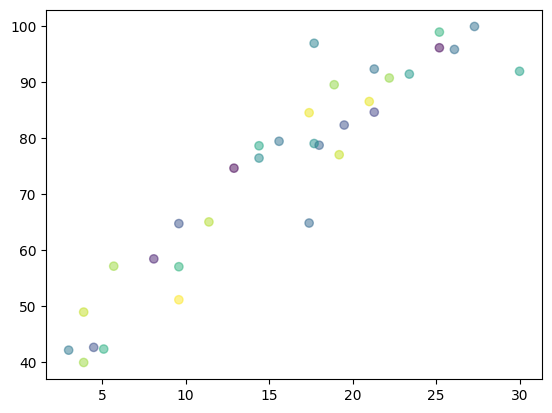

In [27]:
colors = np.random.rand(len(X))
plt.scatter(X, y, alpha=0.5, c=colors)

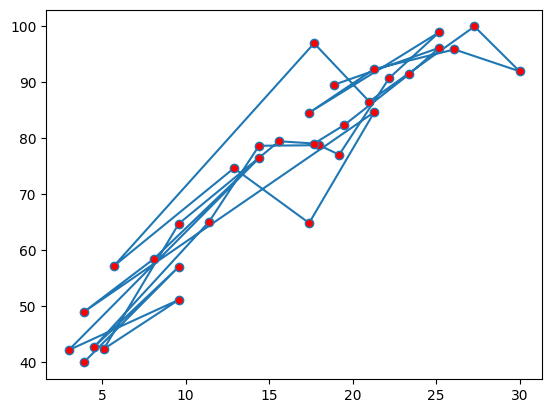

In [28]:
plt.plot(X, y, marker='o', markerfacecolor='red')
# plt.xlabel('Study Hours')
# plt.ylabel('Exam Score')

In [31]:
# test , train split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [32]:
# standardize the data set
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # fit >> data leakage

In [33]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [34]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
print("Coefficient:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient: [16.17860223]
Intercept: 76.9076923076923


In [36]:
# y=76.91 + 16.17*x

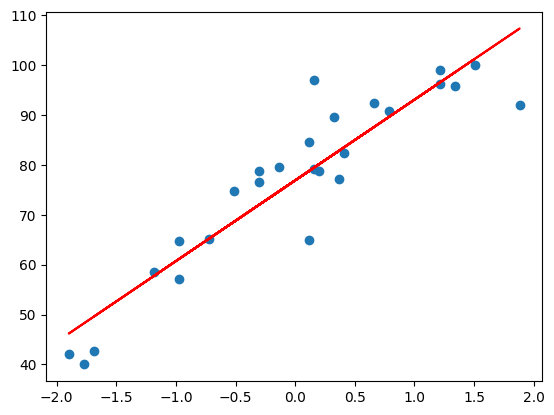

In [37]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),"r")

In [38]:
regression.predict([[20]])

array([400.47973694])

In [39]:
scaler.transform([[20]])

C:\DEV\python\pytorch-tutorials\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [40]:
regression.predict(scaler.transform([[20]]))

C:\DEV\python\pytorch-tutorials\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([84.70590731])

In [41]:
regression.predict(scaler.transform([[0]]))

C:\DEV\python\pytorch-tutorials\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([39.39784252])

In [42]:
# prediction with test data
y_predict_test = regression.predict(X_test)

In [43]:
y_test

25    42.4
14    86.6
30    91.5
16    57.2
24    51.2
20    49.0
19    84.7
Name: Exam Score, dtype: float64

Text(0, 0.5, 'Actual Values')

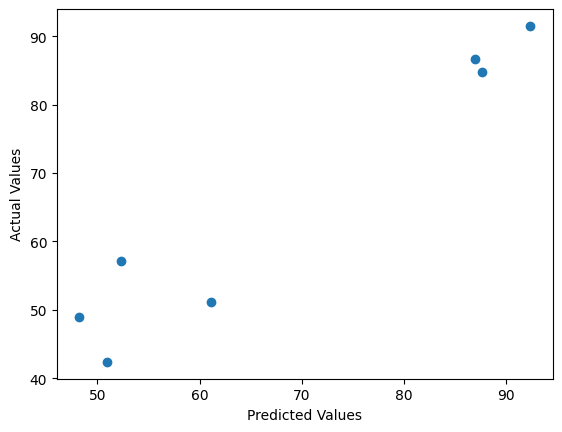

In [44]:
plt.scatter(y_predict_test,y_test)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test,y_predict_test)
mae = mean_absolute_error(y_test,y_predict_test)
rmse = np.sqrt(mse)
print("mse:",mse)
print("mae:",mae)
print("rmse:",rmse)

mse: 29.45839048833392
mae: 4.054868128856142
rmse: 5.427558427906043


In [46]:
r2 = r2_score(y_test,y_predict_test)
print("r2:",r2)

r2: 0.9196596206825491


In [47]:
r2_adjusted = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("r2_adjusted:",r2_adjusted)

r2_adjusted: 0.903591544819059
